In [7]:
import sys
import nibabel as nib
import numpy as np
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from CalculateMeasures import calculate_measures_dataframe, calculate_measures
from glob import glob
from liver_metastasis_dataset_3D import LiverTumorsDataset3D, LIVER_LESIONS_DATASET
import itertools
import torch
from sklearn.cluster import KMeans
from skimage import measure
from typing import TypeVar
from monai.inferers import SliceInferer, PatchInferer, SlidingWindowSplitter, Inferer
import einops as E
import matplotlib.pyplot as plt
from collections import Counter
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from CalculateMeasures import calculate_measures_dataframe, calculate_measures
import os

In [2]:
d_support = LiverTumorsDataset3D(split="support", support_frac=0.1, label=1, resize_scan=False)

100%|██████████| 10/10 [00:21<00:00,  2.20s/it]


In [4]:
PATCH_SIZE=(128, 128)
T = TypeVar('T', torch.Tensor, np.ndarray)
np.random.seed(42)

In [5]:
support_images, support_labels, support_filenames = zip(*itertools.islice(d_support, 10))
support_images = torch.cat(support_images, dim=0)
support_labels = torch.cat(support_labels, dim=0)

In [6]:
support_images.shape

torch.Size([303, 1, 512, 512])

In [7]:
def get_positive_patches_idx(masks: T) -> np.ndarray:
    # Label connected components in the mask
    positive_masks = []
    for i, mask in enumerate(masks):
        mask = mask.reshape((1, 128, 128))
        if torch.is_tensor(mask):
            mask = mask.cpu().detach().numpy()
        labels = measure.label(mask, background=0)
        # Loop through each labeled region
        if np.any(labels):
            for region in measure.regionprops(labels):
                # check if region is bigger than some minimal area threshold
                if region.area > 30:
                    positive_masks.append(i)
    return np.unique(positive_masks).astype(int)

def get_support_patches(support_images: torch.Tensor, support_labels: torch.Tensor,
                        patch_size: tuple[int, int] = (64, 64)) -> tuple[torch.Tensor, torch.Tensor]:
    splitter = SlidingWindowSplitter(patch_size=patch_size, overlap=0.5, device="cpu")
    # eliminate all negative patches
    images_patches = torch.concat([t[0] for t in splitter(support_images[0])])
    labels_patches = torch.concat([t[0] for t in splitter(support_labels[0])])
    positive_patches_idx = get_positive_patches_idx(labels_patches)
    images_patches = images_patches[positive_patches_idx]
    labels_patches = labels_patches[positive_patches_idx]
    return images_patches, labels_patches

In [8]:
support_images_patches, support_labels_patches = get_support_patches(support_images[None], support_labels[None], patch_size=PATCH_SIZE)

In [9]:
support_labels_patches.shape

torch.Size([1666, 1, 128, 128])

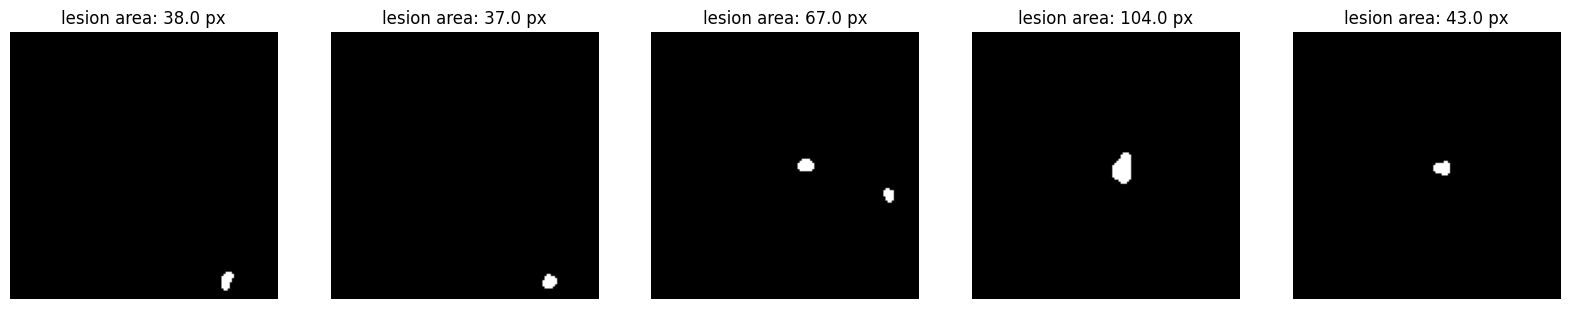

In [10]:
# show some patches
fig, axs = plt.subplots(1, 5, figsize=(20, 20))
for i, ax in enumerate(axs.flat):
    ax.imshow(support_labels_patches[i+200][0], cmap='gray')
    ax.set_title(f"lesion area: {support_labels_patches[i+200][0].sum()} px")
    ax.axis('off')

In [14]:
support_labels_patches_reshaped = E.rearrange(support_labels_patches, "N 1 W H -> N (H W)")
support_labels_patches_reshaped.shape

torch.Size([1666, 16384])

In [15]:
num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(support_labels_patches_reshaped)

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning


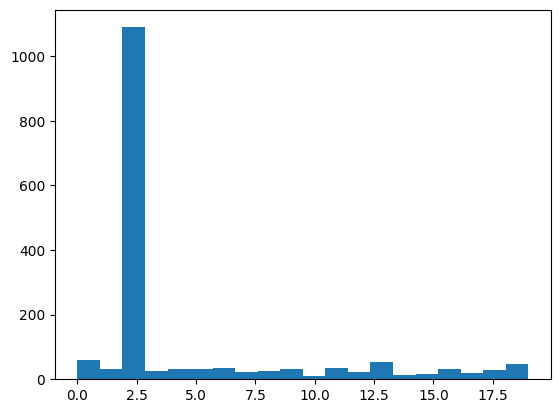

In [16]:
# plot the frequency of each cluster
plt.hist(kmeans.labels_, bins=num_clusters)
plt.show()

In [17]:
# get the item that appears the most in cluster_labels
most_common, freq = Counter(cluster_labels).most_common(1)[0]
print("most common label:", most_common, "appears:", freq)

most common label: 2 appears: 1089


In [18]:
most_common_cluster_label = Counter(cluster_labels).most_common(1)[0][0]
images_in_most_common_cluster = support_labels_patches_reshaped[cluster_labels == most_common_cluster_label]
print(f'Most common cluster has: {len(images_in_most_common_cluster)} patches')
centroid_of_most_common_cluster = torch.mean(images_in_most_common_cluster, dim=0).reshape(PATCH_SIZE)
centroid_of_most_common_cluster

Most common cluster has: 1089 patches


tensor([[0.0119, 0.0119, 0.0129,  ..., 0.0358, 0.0275, 0.0211],
        [0.0138, 0.0138, 0.0138,  ..., 0.0285, 0.0230, 0.0211],
        [0.0138, 0.0147, 0.0147,  ..., 0.0220, 0.0220, 0.0220],
        ...,
        [0.0312, 0.0257, 0.0165,  ..., 0.0064, 0.0064, 0.0073],
        [0.0257, 0.0174, 0.0110,  ..., 0.0055, 0.0064, 0.0073],
        [0.0147, 0.0119, 0.0101,  ..., 0.0073, 0.0055, 0.0083]])

Let's take a closer look at what the most common cluster contains, and maybe reveal some information about it.

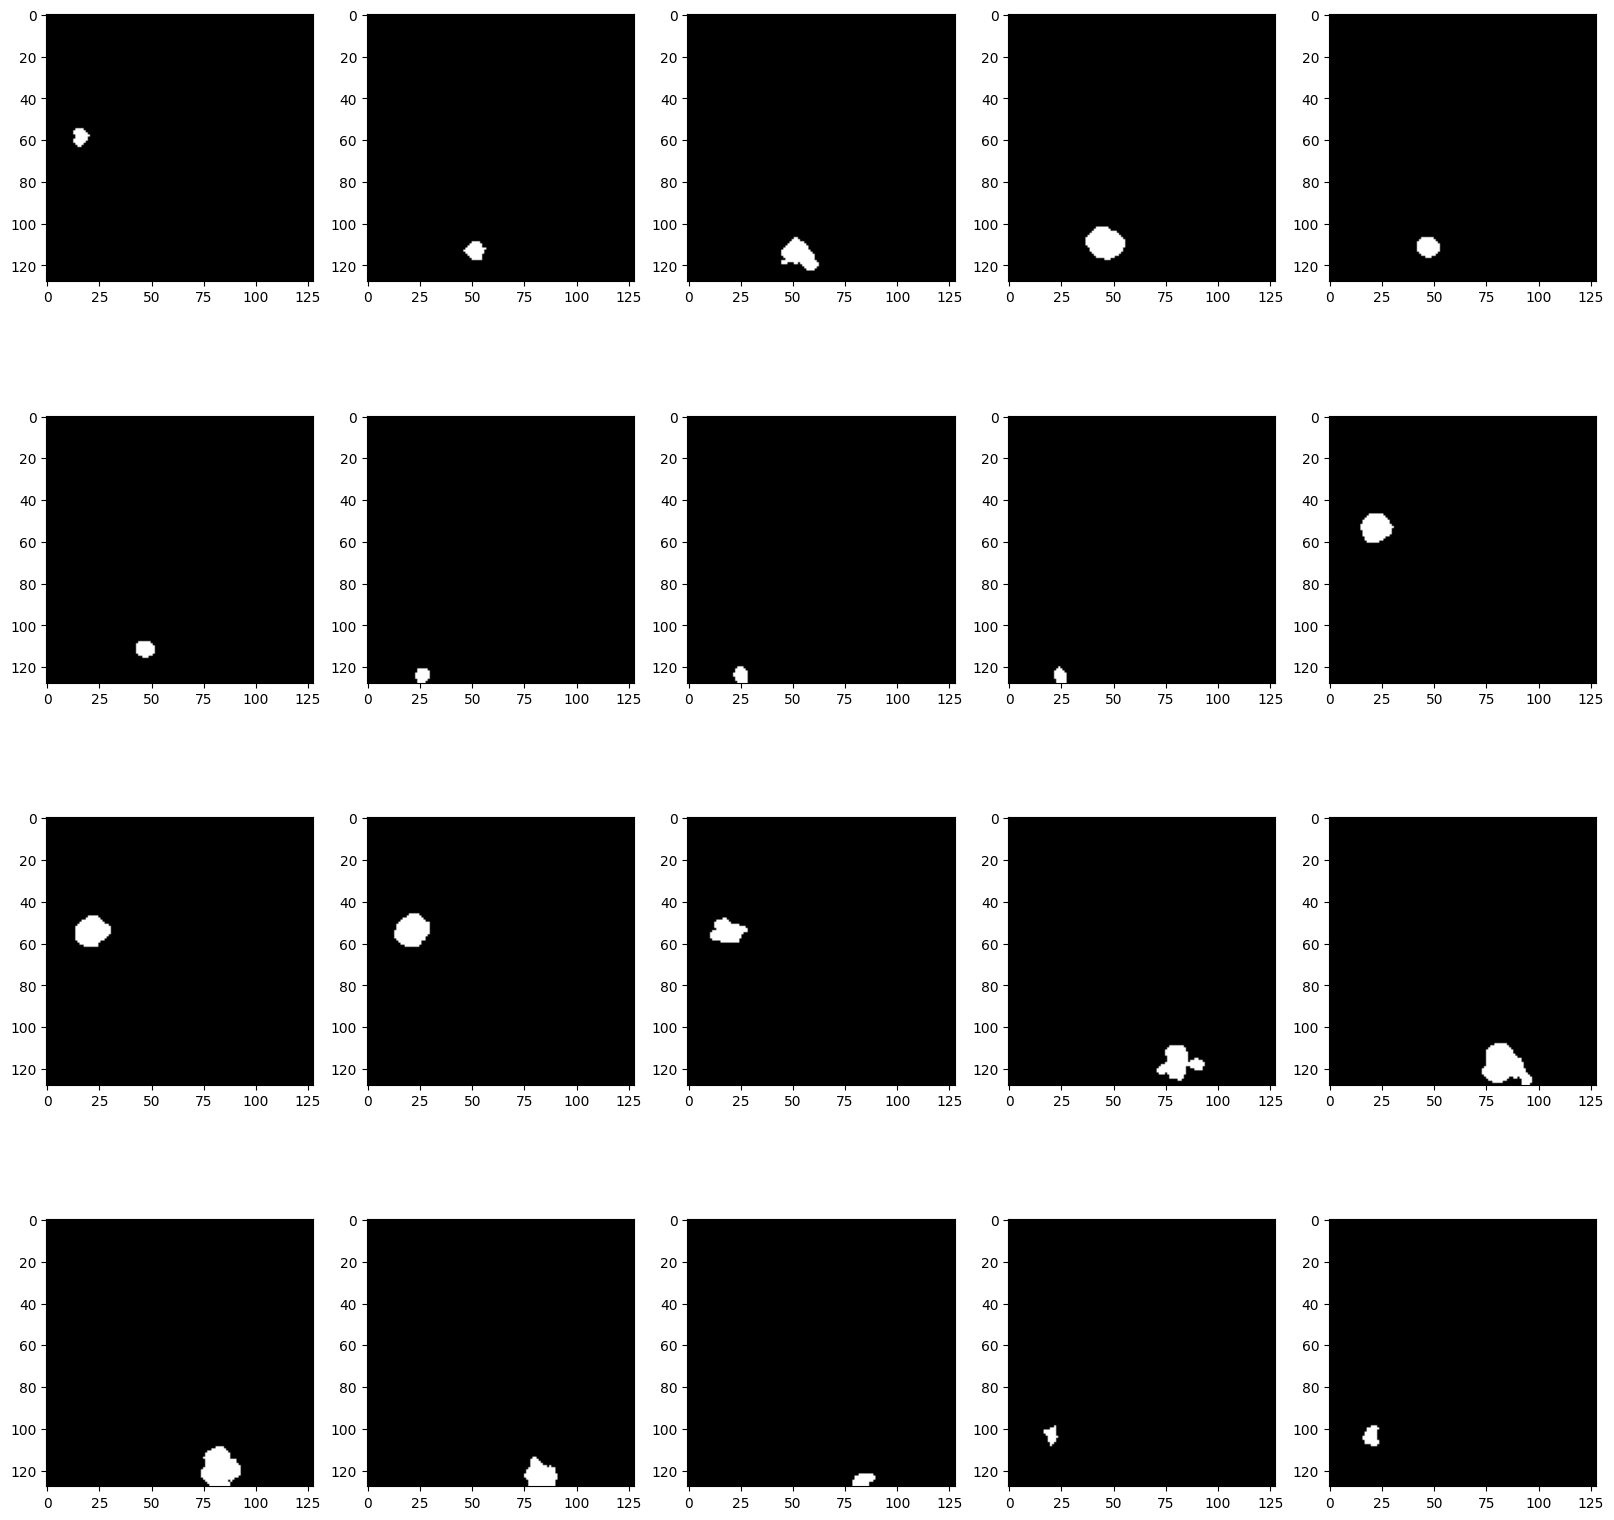

In [32]:
fig, axs = plt.subplots(4, 5, figsize=(20, 20))
for img, ax in zip(images_in_most_common_cluster[600:620], axs.flat):
    ax.imshow(img.reshape(128, 128), cmap="gray")

Indeed those patches contain mostly small and lesions without meaningful data, as it seems. Maybe running more clusters will obtain more interesting results?

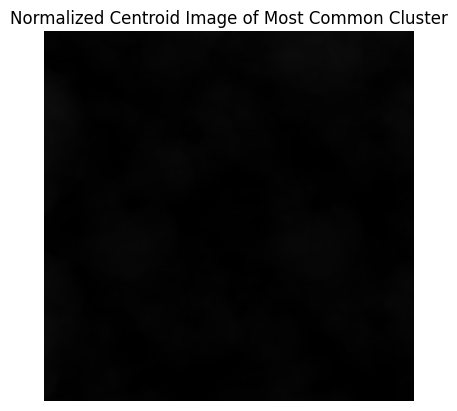

In [27]:
# Plot the centroid image
centroid_image_normalized = (centroid_of_most_common_cluster - torch.min(centroid_of_most_common_cluster)) / (torch.max(centroid_of_most_common_cluster) - torch.min(centroid_of_most_common_cluster))
plt.imshow(centroid_of_most_common_cluster, cmap='gray', vmin=0, vmax=1)
plt.title('Normalized Centroid Image of Most Common Cluster')
plt.axis('off')
plt.show()

Note that the most common cluster actually does not contain anything. This is an interesting observation, as this means that most of the patches we use for the support set are considered as empty images.

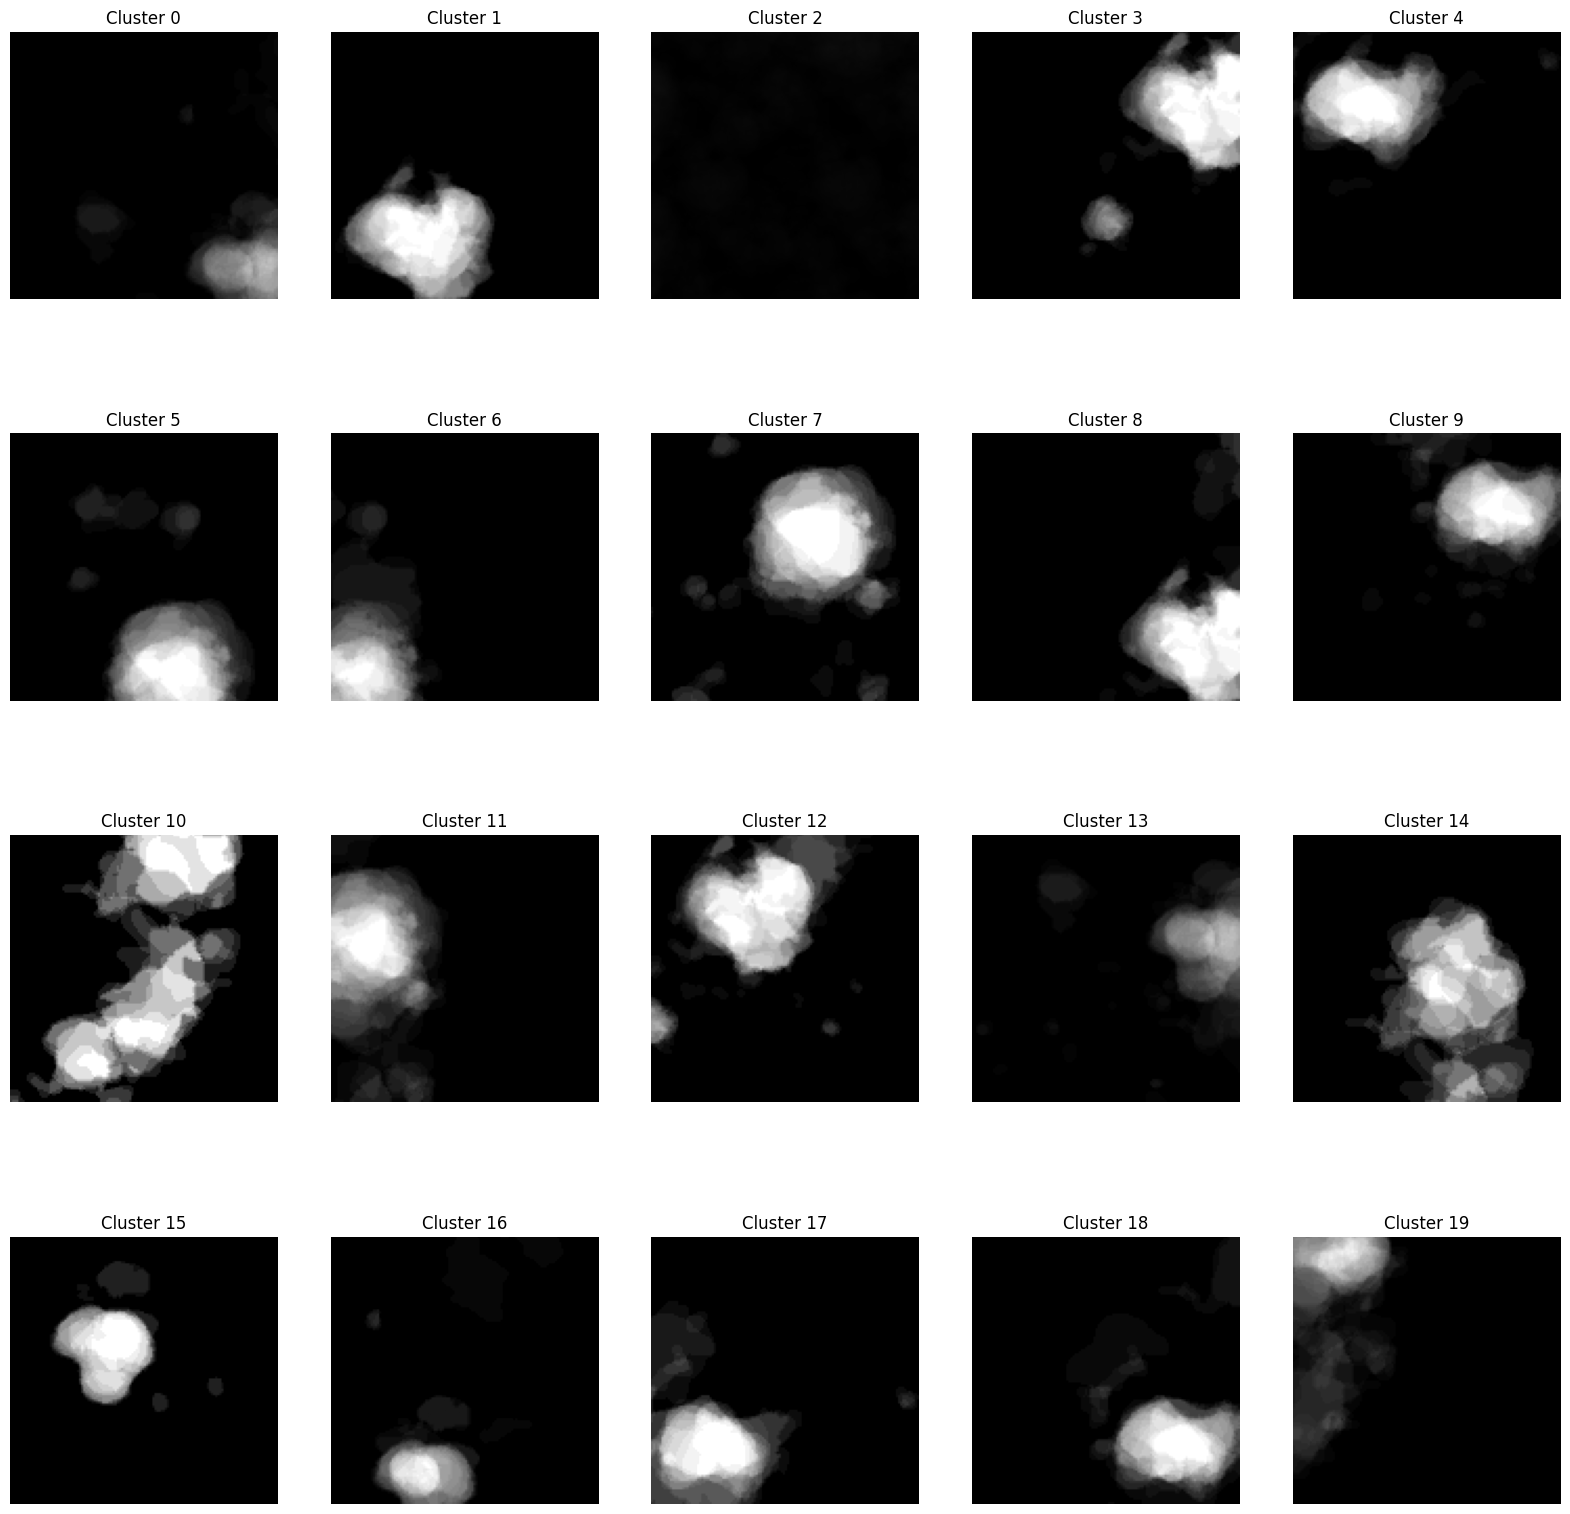

In [25]:
# for each cluster centroid, plot the centroid image. Plot them in a grid
fig, axs = plt.subplots(4, 5, figsize=(20, 20))
for i, ax in enumerate(axs.flat):
    centroid_of_cluster = torch.mean(support_labels_patches_reshaped[cluster_labels == i], dim=0).reshape(PATCH_SIZE)
    ax.imshow(centroid_of_cluster, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Cluster {i}')
    ax.axis('off')

This indeed supports the observation that most of the patches are empty. Thus, we might want to use patches that are close to the clusters contain data.

We would like to see if clustering of fewer classes will provide us more presentitive patches. Let's examine k=10.

In [37]:
num_clusters = 100
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(support_labels_patches_reshaped)

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning


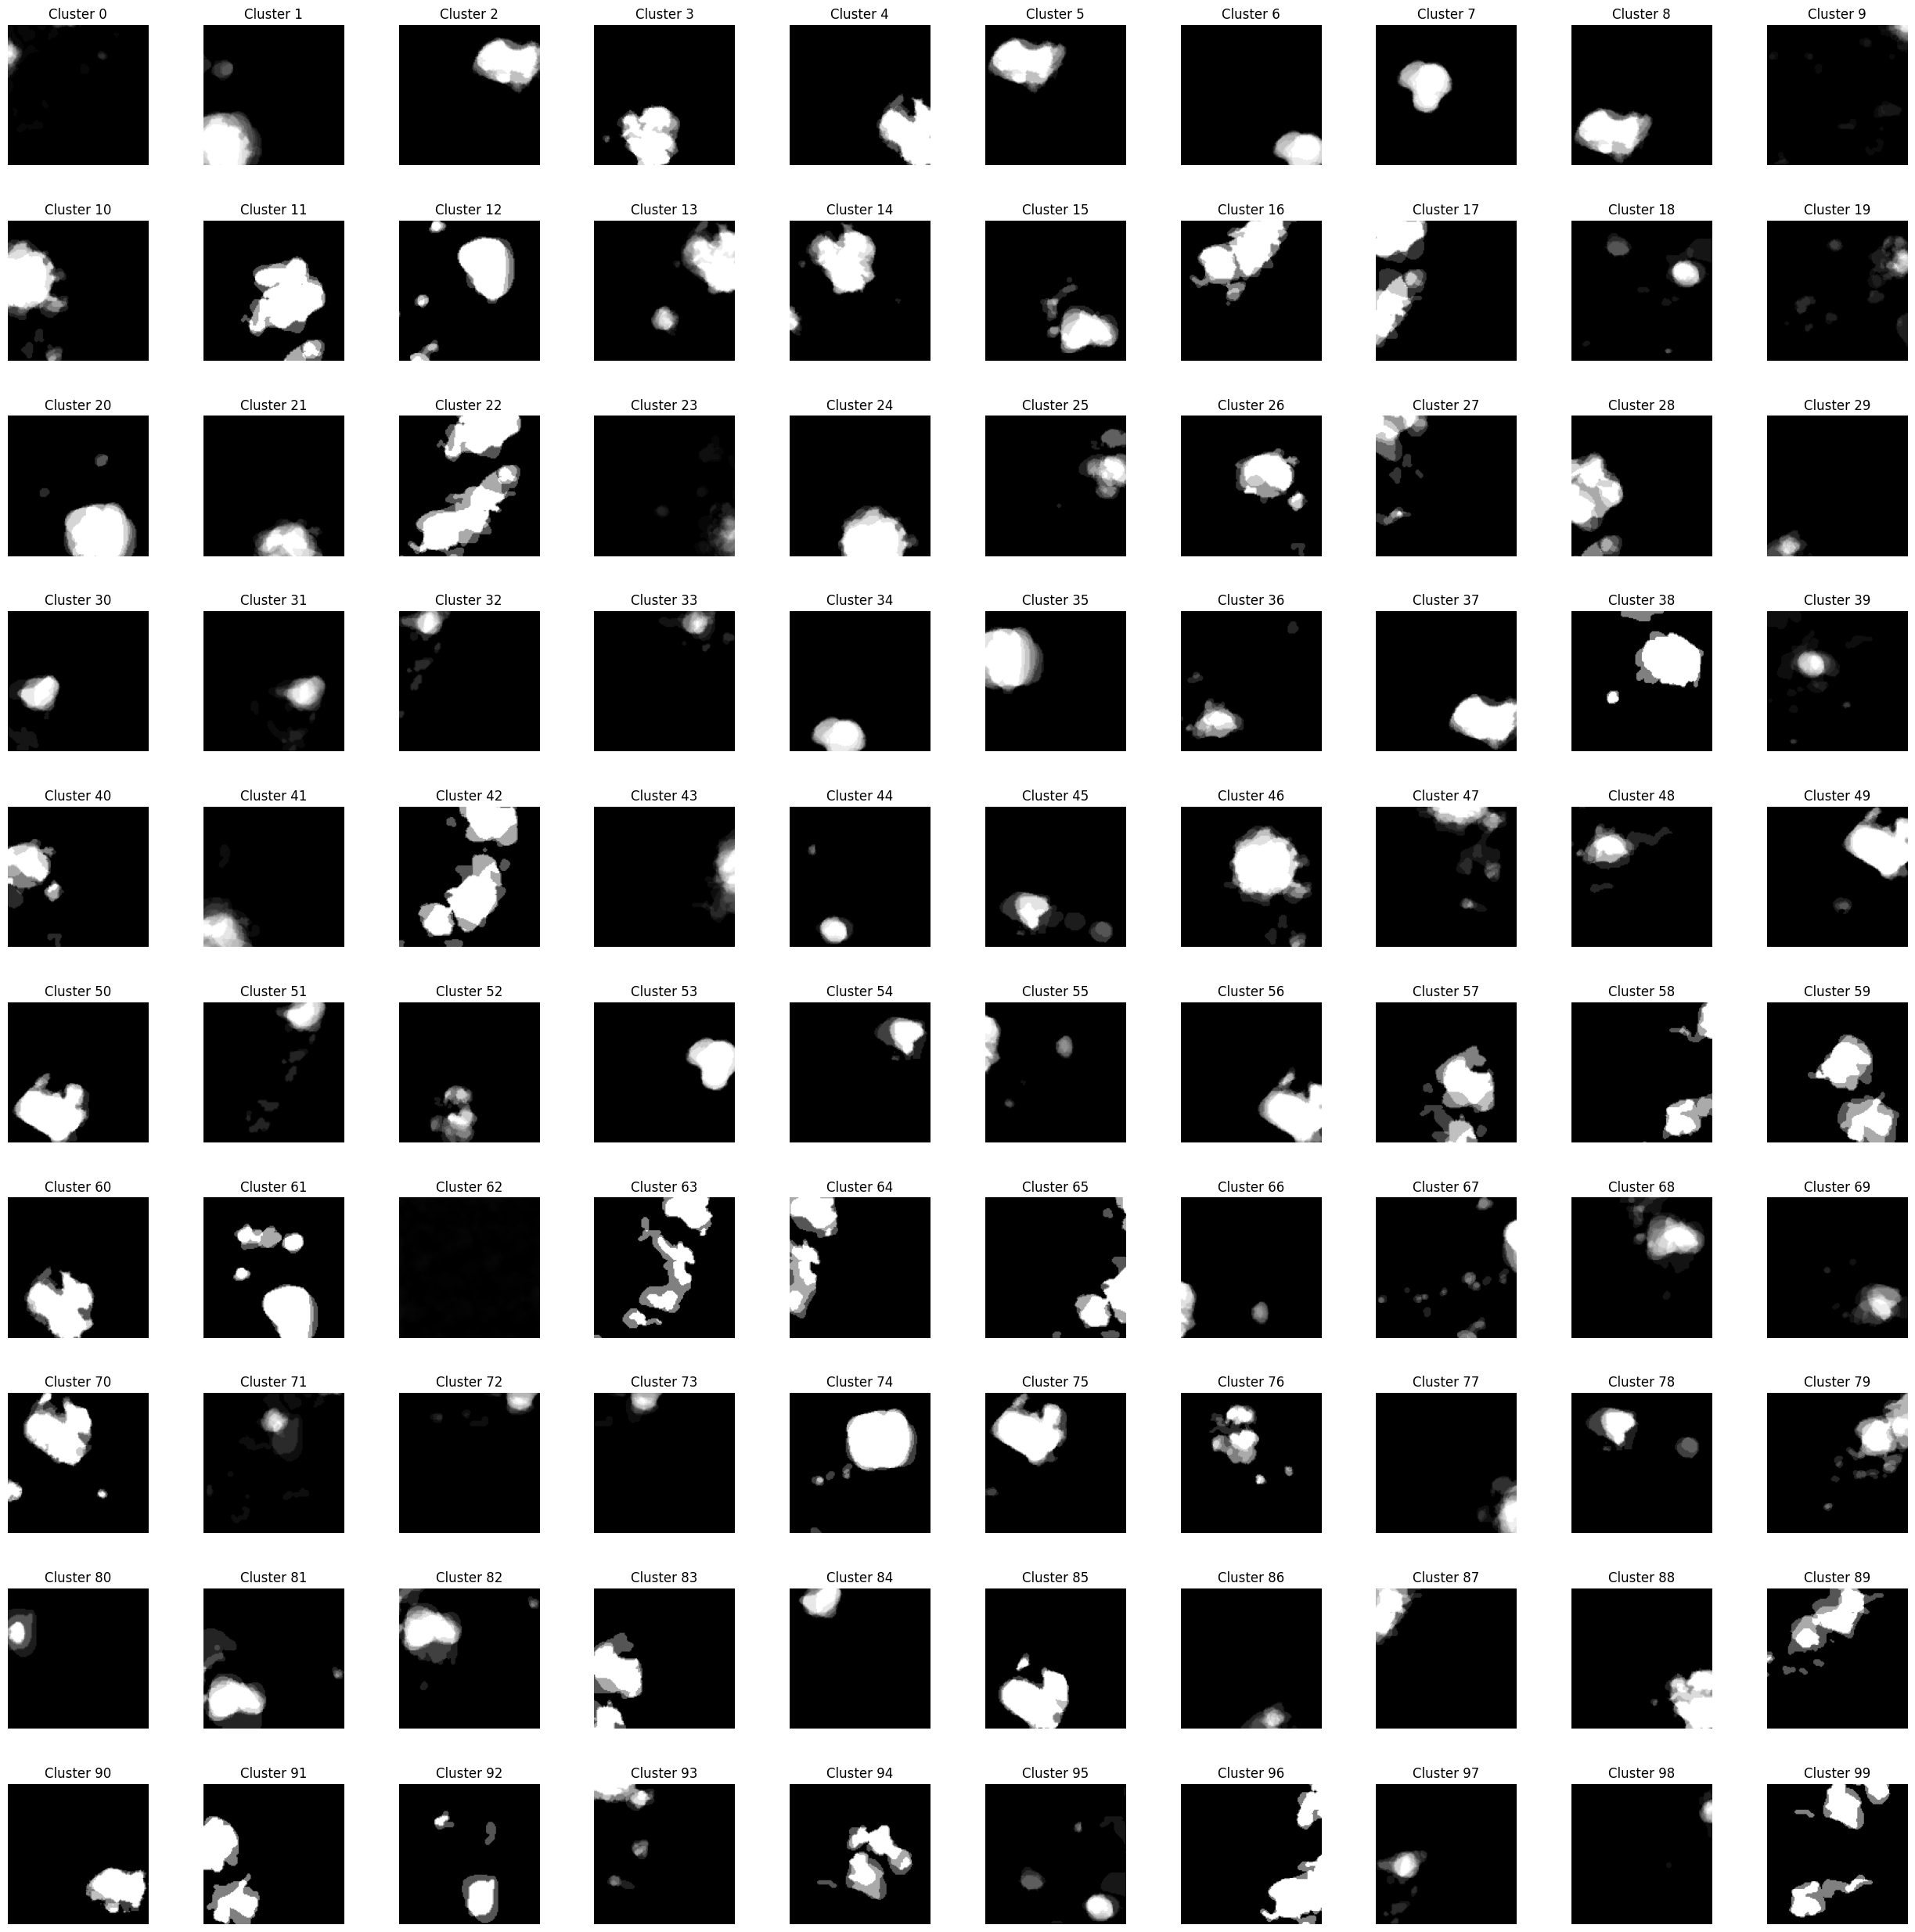

In [38]:
# for each cluster centroid, plot the centroid image. Plot them in a grid
fig, axs = plt.subplots(10, 10, figsize=(25, 25))
fig.tight_layout(h_pad=2, w_pad=2)


for i, ax in enumerate(axs.flat):
    centroid_of_cluster = torch.mean(support_labels_patches_reshaped[cluster_labels == i], dim=0).reshape(PATCH_SIZE)
    ax.imshow(centroid_of_cluster, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Cluster {i}')
    ax.set_aspect('equal')
    ax.axis('off')

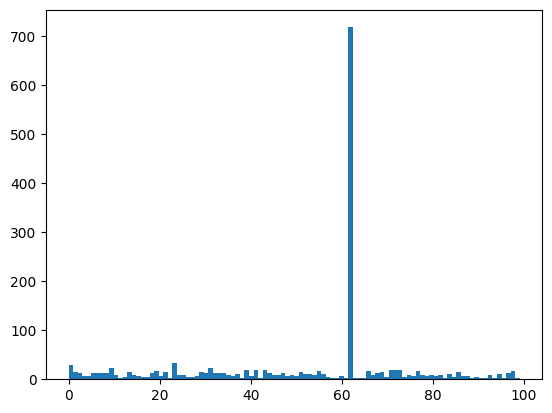

In [39]:
# plot the frequency of each cluster
plt.hist(kmeans.labels_, bins=num_clusters)
plt.show()

Conclusion - more clusters less exportability in the distribution. We will use k=20 for the clustering.
Let's create the support set that contains the patches that are close to the cluster centroids that do contain data. Since we cannot take all images that are closer to the cluster

#### Prepare the dataset for support

In [ ]:
def get_support_patches_by_clustering(support_patches_images: torch.Tensor, support_patches_labels: torch.Tensor,
                                      num_clusters: int, support_size:int = 450) -> tuple[torch.Tensor, torch.Tensor]:
    kmeans_clusters = KMeans(n_clusters=num_clusters, random_state=42)
    support_labels_patches_reshaped = E.rearrange(support_labels_patches, "N 1 W H -> N (H W)")
    cluster_labels = kmeans_clusters.fit_predict(support_labels_patches_reshaped)
    unique, counts = np.unique(cluster_labels, return_counts=True)
    # remove the most frequent cluster from cluster labels
    unique = np.delete(unique, np.argmax(counts))
    counts = np.delete(counts, np.argmax(counts)).astype('float64')
    probabilities = {c: p for c, p in zip(unique, np.true_divide(counts, np.sum(counts)))}

    indices = np.where(np.isin(cluster_labels, unique))[0]
    clusters_labels_filtered = cluster_labels[indices]
    indices_probabilities = np.array([probabilities[c] for c in clusters_labels_filtered])
    indices_probabilities = indices_probabilities / np.sum(indices_probabilities)
    randomized_patches_indices = np.random.choice(indices, size=support_size, replace=False, p=indices_probabilities)
    return torch.index_select(support_patches_images, 0, torch.tensor(randomized_patches_indices)), torch.index_select(support_patches_labels, 0, torch.tensor(randomized_patches_indices))

In [ ]:
images, labels = get_support_patches_by_clustering(support_images_patches, support_labels_patches, 20)

In [ ]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*_support_analysis_10.nii.gz")))
gt_list = [p.replace("support_analysis_10.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_10.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./support_clustering_analysis_K10.xlsx", roi_list=roi_list)

In [ ]:
images, labels = get_support_patches_by_clustering(support_images_patches, support_labels_patches, 20)

In [ ]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*_support_analysis_10.nii.gz")))
predictions_list = [p for p in predictions_list if "soft_prediction" not in p]
gt_list = [p.replace("support_analysis_10.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_10.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./support_clustering_analysis_K10.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 93/93 [00:00<00:00, 98428.03it/s]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/cs/labs/josko/alina.ryabtsev/venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1852315/445286555.py", line 5, in <cell line: 5>
    calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./support_clustering_analysis_K10.xlsx", roi_list=roi_list)
  File "/cs/casmip/alina.ryabtsev/Tools/CalculateMeasures.py", line 89, in calculate_measures
    results = p.starmap(partial(cm.calculate_stats, th=th),
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 372, in starmap
    return self._map_async(func, iterable, starmapstar, chunksize).get()
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 765, in get
    self.wait(timeout)
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 762, in wait
    self._event.wait(timeout)
  File "/usr/lib/python3.9/threading.py", line 574, in wait
    signal

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/cs/labs/josko/alina.ryabtsev/venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1852315/445286555.py", line 5, in <cell line: 5>
    calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./support_clustering_analysis_K10.xlsx", roi_list=roi_list)
  File "/cs/casmip/alina.ryabtsev/Tools/CalculateMeasures.py", line 89, in calculate_measures
    results = p.starmap(partial(cm.calculate_stats, th=th),
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 372, in starmap
    return self._map_async(func, iterable, starmapstar, chunksize).get()
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 765, in get
    self.wait(timeout)
  File "/usr/lib/python3.9/multiprocessing/pool.py", line 762, in wait
    self._event.wait(timeout)
  File "/usr/lib/python3.9/threading.py", line 574, in wait
    signal